# Performance Analysis — Filter Lock vs Bakery Lock

This notebook visualizes benchmark results comparing two mutual-exclusion (locking) algorithms implemented in C++ — **Filter Lock** and **Bakery Lock** (see `../Implementation/filter_lock.cpp` and `../Implementation/bakery_lock.cpp`). Both guarantee mutual exclusion, are deadlock-free and starvation-free, but differ in *how* threads coordinate to enter the critical section (CS):

- **Filter Lock** — threads climb through N-1 "filter" levels, each level eliminating at least one contender, using a level/victim scheme.
- **Bakery Lock** — each thread draws a ticket number and waits until it holds the lowest number among all threads wanting to enter (like a queue at a bakery counter).

Each program was run with different `input_params.txt` configurations (number of threads, number of times each thread enters the CS) via `../Input-Output/`, and the results — throughput and lock-acquisition time — were recorded and are plotted below along two axes: **number of threads** and **number of CS entries per thread**.

## 1. Throughput vs. Number of Threads

**Setup:** each thread enters the critical section a fixed number of times; the number of concurrent threads is varied from 2 to 64.
**Metric:** throughput = (total CS entries) / (total execution time).

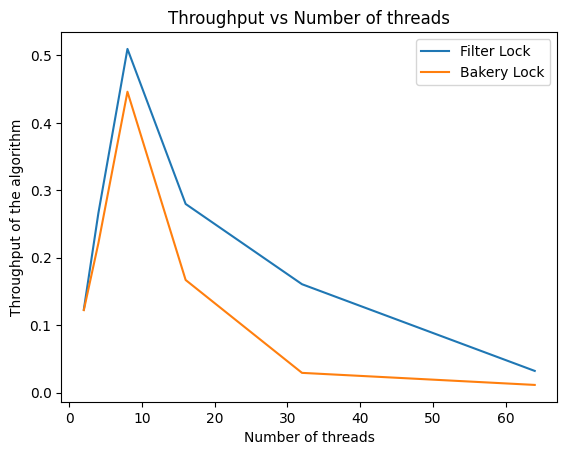

In [2]:
import matplotlib.pyplot as plt

x = [2,4,8,16,32,64]
y1 = [0.123209, 0.265991, 0.509478, 0.279701, 0.160757, 0.032264]
y2 = [0.12234, 0.22143, 0.446014, 0.16703, 0.0293618, 0.0115016]

plt.plot(x, y1, label = "Filter Lock")

plt.plot(x, y2, label = "Bakery Lock")

plt.xlabel('Number of threads')

plt.ylabel('Throughput of the algorithm')

plt.title('Throughput vs Number of threads')

plt.legend()

plt.show()


**Observation:** throughput for both algorithms rises with thread count up to a point (peaking around 8 threads) — more threads means more work gets done in parallel — but then falls sharply as contention for the lock dominates. Filter Lock sustains higher throughput than Bakery Lock at every thread count, and the gap widens as the thread count grows.

## 2. Throughput vs. Number of Times in the Critical Section

**Setup:** thread count is fixed; the number of times each thread re-enters the critical section is varied from 5 to 25.
**Metric:** throughput, as above.

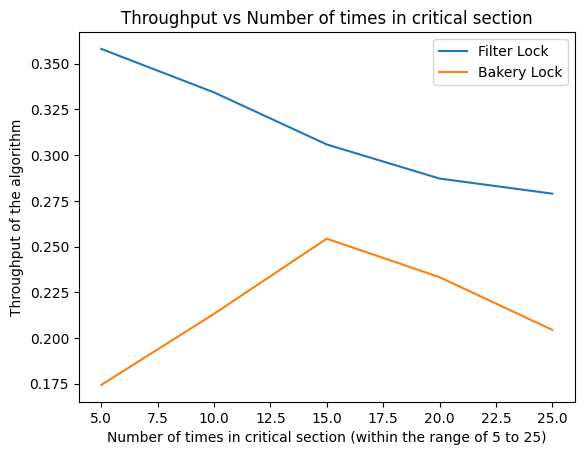

In [3]:
import matplotlib.pyplot as plt

x = [5, 10, 15, 20, 25]
y1 = [0.358054, 0.334272, 0.305803, 0.287171, 0.278918]
y2 = [0.174311, 0.213186, 0.254296, 0.233225, 0.204432]

plt.plot(x, y1, label = "Filter Lock")

plt.plot(x, y2, label = "Bakery Lock")

plt.xlabel('Number of times in critical section (within the range of 5 to 25)')

plt.ylabel('Throughput of the algorithm')

plt.title('Throughput vs Number of times in critical section')

plt.legend()

plt.show()

**Observation:** Filter Lock's throughput decreases steadily as each thread does more repeated CS work. Bakery Lock's throughput is lower overall and behaves less predictably (rising, then falling), reflecting the added overhead of its ticket-comparison scheme under sustained contention.

## 3. Lock-Acquisition Time vs. Number of Threads

**Setup:** same sweep as Graph 1 (threads: 2 → 64).
**Metric:** average and worst-case time (ms) a thread waits to acquire the lock and enter the CS.

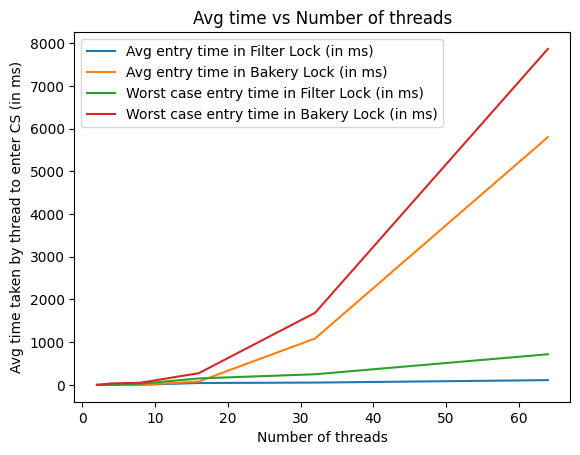

In [4]:
import matplotlib.pyplot as plt

x = [2,4,8,16,32,64]
y1 = [0.06633, 0.361847, 3.45647, 44.9585, 54.7694, 112.216 ]
y2 = [0.411285, 2.92968, 4.04798, 79.4609, 1088.08, 5800.15   ]
y3 = [0.2531, 0.9684, 28.2492, 152.458, 249.71, 717.525 ]
y4 = [0.6444, 34.9989, 51.8402, 274.512, 1688.62, 7865.64 ]

plt.plot(x, y1, label = "Avg entry time in Filter Lock (in ms)")

plt.plot(x, y2, label = "Avg entry time in Bakery Lock (in ms)")

plt.plot(x, y3, label = "Worst case entry time in Filter Lock (in ms)")

plt.plot(x, y4, label = "Worst case entry time in Bakery Lock (in ms)")

plt.xlabel('Number of threads')

plt.ylabel('Avg time taken by thread to enter CS (in ms)')

plt.title('Avg time vs Number of threads')

plt.legend()

plt.show()

**Observation:** this is the starkest difference between the two algorithms. Filter Lock's average and worst-case entry times grow only gently with thread count (up to ~112ms / ~718ms at 64 threads). Bakery Lock's entry times grow near-exponentially — average entry time reaches ~5800ms and worst-case ~7866ms at 64 threads. This matches Bakery Lock's design: every acquisition attempt compares its ticket against *every other thread's* ticket (O(N) per acquisition), so cost grows sharply as N increases — Filter Lock has no equivalent all-pairs scan.

## 4. Lock-Acquisition Time vs. Number of Times in the Critical Section

**Setup:** same sweep as Graph 2 (CS entries per thread: 5 → 25).
**Metric:** average and worst-case entry time (ms), as above.

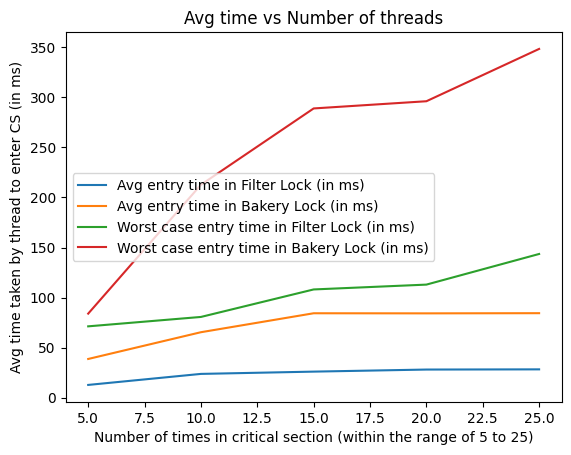

In [1]:
import matplotlib.pyplot as plt

x = [5,10,15,20,25]
y1 = [12.665, 23.6816, 25.9561, 28.0256, 28.2174   ]
y2 = [38.6017, 65.3405, 84.2874, 84.1918, 84.365  ]
y3 = [71.2142, 80.6069, 108.09, 112.922, 143.544   ]
y4 = [83.9232, 212.722, 288.995, 296.191 , 348.482]

plt.plot(x, y1, label = "Avg entry time in Filter Lock (in ms)")

plt.plot(x, y2, label = "Avg entry time in Bakery Lock (in ms)")

plt.plot(x, y3, label = "Worst case entry time in Filter Lock (in ms)")

plt.plot(x, y4, label = "Worst case entry time in Bakery Lock (in ms)")

plt.xlabel('Number of times in critical section (within the range of 5 to 25)')

plt.ylabel('Avg time taken by thread to enter CS (in ms)')

plt.title('Avg time vs Number of threads')

plt.legend()

plt.show()

**Observation:** the same pattern holds under sustained repeated access — Bakery Lock's average entry time is consistently ~2-3x Filter Lock's, and its worst-case time grows notably faster (up to ~348ms vs. Filter Lock's ~144ms at 25 CS entries).

## Conclusion

Across all four experiments, **Filter Lock consistently outperforms Bakery Lock** — higher throughput and lower average/worst-case lock-acquisition time — with the gap widening as contention increases (more threads) or as threads do more repeated CS work. The likely reason is structural: Bakery Lock's ticket scheme requires each thread to compare its number against every other thread's on every acquisition (O(N) work per lock), while Filter Lock's level/victim scheme does not scale the same way with thread count. Both algorithms remain correct (mutual exclusion, deadlock-free, starvation-free) — the difference here is purely one of *performance* under contention, not correctness.